In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_csv('data/global_supply_chain_risk_2026.csv')

In [78]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [79]:
df['Date'] = pd.to_datetime(df['Date'])

In [80]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek

In [81]:
df = df.drop('Date', axis=1)

In [82]:
df.head()

,Shipment_ID,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,year,month,day_of_week
0,SC-10000,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,2025,10,3
1,SC-10001,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,2024,4,2
2,SC-10002,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2024,1,4
3,SC-10003,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,2024,10,1
4,SC-10004,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,2024,9,5


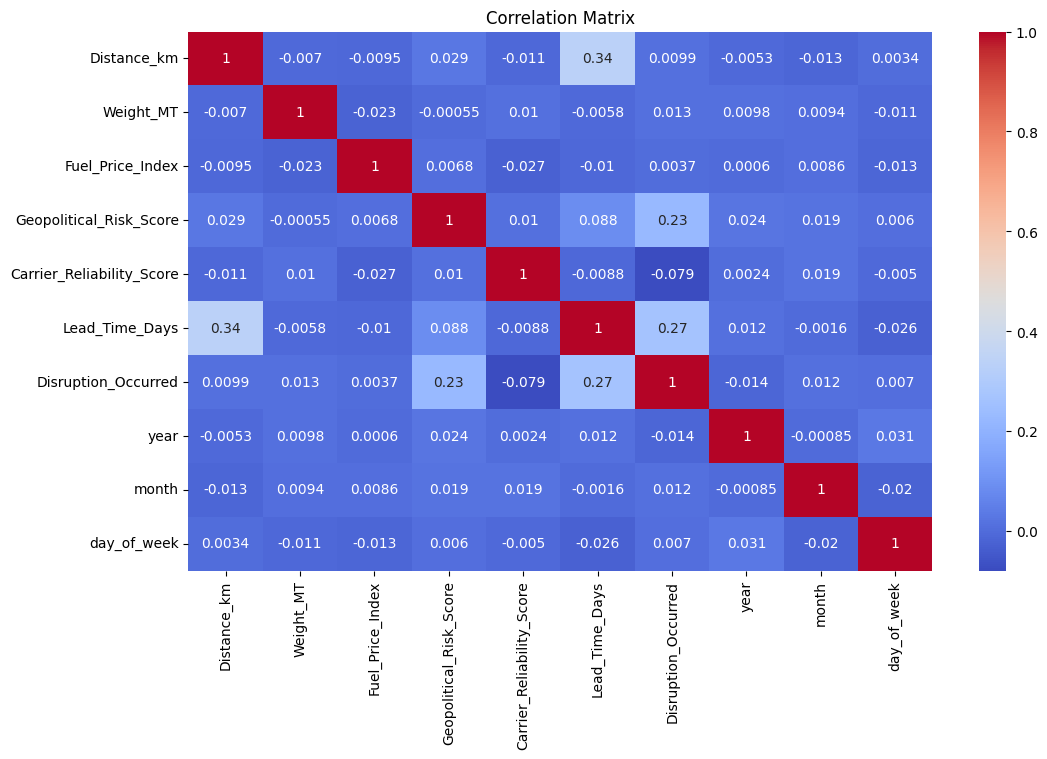

In [83]:
plt.figure(figsize=(12,7), dpi=100)
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [84]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_curve,
)

In [85]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

In [86]:
cat_cols_id = cat_cols.pop(0)

In [87]:
cat_cols

['Origin_Port',
 'Destination_Port',
 'Transport_Mode',
 'Product_Category',
 'Weather_Condition']

In [88]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [89]:
df.head()

,Shipment_ID,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,year,month,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
0,SC-10000,5930.83,197.42,2.43,5.0,0.865,41.39,1,2025,10,...,False,False,False,False,False,True,False,True,False,False
1,SC-10001,14285.36,237.24,2.30,7.5,0.592,40.92,1,2024,4,...,False,False,False,False,False,False,False,False,False,True
2,SC-10002,11113.91,427.42,1.78,5.6,0.673,11.54,0,2024,1,...,False,False,False,True,False,False,False,False,True,False
3,SC-10003,9180.55,170.66,3.20,0.8,0.832,53.13,1,2024,10,...,False,False,True,False,False,False,False,True,False,False
4,SC-10004,2762.27,434.96,2.77,1.9,0.741,0.50,1,2024,9,...,False,False,False,True,False,False,True,False,False,False


In [90]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

In [91]:
df.head()

,Shipment_ID,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,year,month,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
0,SC-10000,5930.83,197.42,2.43,5.0,0.865,41.39,1,2025,10,...,0,0,0,0,0,1,0,1,0,0
1,SC-10001,14285.36,237.24,2.30,7.5,0.592,40.92,1,2024,4,...,0,0,0,0,0,0,0,0,0,1
2,SC-10002,11113.91,427.42,1.78,5.6,0.673,11.54,0,2024,1,...,0,0,0,1,0,0,0,0,1,0
3,SC-10003,9180.55,170.66,3.20,0.8,0.832,53.13,1,2024,10,...,0,0,1,0,0,0,0,1,0,0
4,SC-10004,2762.27,434.96,2.77,1.9,0.741,0.50,1,2024,9,...,0,0,0,1,0,0,1,0,0,0


In [92]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [93]:
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,year,month,day_of_week,...,Transport_Mode_Road,Transport_Mode_Sea,Product_Category_Electronics,Product_Category_Perishables,Product_Category_Pharmaceuticals,Product_Category_Textiles,Weather_Condition_Fog,Weather_Condition_Hurricane,Weather_Condition_Rain,Weather_Condition_Storm
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600,2024.509000,6.564400,3.044400,...,0.242800,0.256200,0.20320,0.201800,0.201200,0.202000,0.207200,0.198000,0.195400,0.20040
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205,0.499969,3.463387,1.999707,...,0.428818,0.436577,0.40242,0.401384,0.400937,0.401532,0.405341,0.398532,0.396548,0.40034
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000,2024.000000,1.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000,2024.000000,4.000000,1.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000,2025.000000,7.000000,3.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000,2025.000000,10.000000,5.000000,...,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000,2025.000000,12.000000,6.000000,...,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Shipment_ID                       5000 non-null   object 
 1   Distance_km                       5000 non-null   float64
 2   Weight_MT                         5000 non-null   float64
 3   Fuel_Price_Index                  5000 non-null   float64
 4   Geopolitical_Risk_Score           5000 non-null   float64
 5   Carrier_Reliability_Score         5000 non-null   float64
 6   Lead_Time_Days                    5000 non-null   float64
 7   Disruption_Occurred               5000 non-null   int64  
 8   year                              5000 non-null   int32  
 9   month                             5000 non-null   int32  
 10  day_of_week                       5000 non-null   int32  
 11  Origin_Port_Busan                 5000 non-null   int64  
 12  Origin

<Axes: xlabel='Disruption_Occurred', ylabel='count'>

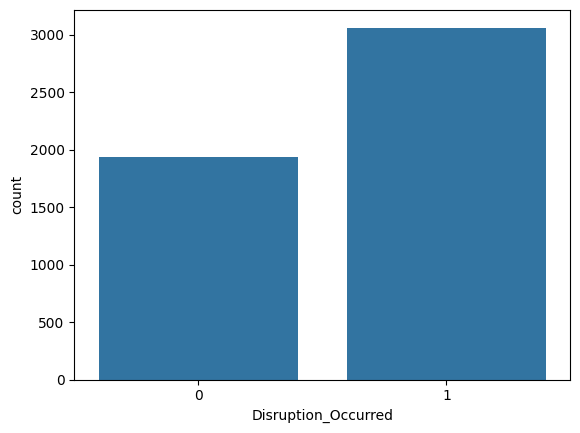

In [95]:
sns.countplot(data=df, x='Disruption_Occurred')

In [96]:
drop_cols = ['Shipment_ID', 'Disruption_Occurred']

In [97]:
X = df.drop(drop_cols, axis=1)
y = df['Disruption_Occurred']

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

selector = Pipeline([
    ('variance', VarianceThreshold(threshold=0.01)),  
    ('kbest', SelectKBest(f_classif, k=6))          
])

selector.fit(X_train, y_train)

X_train_filtered = selector.transform(X_train)
X_test_filtered = selector.transform(X_test)
X = selector.transform(X)

In [100]:
variance_mask = selector['variance'].get_support()
kbest_mask = selector['kbest'].get_support()

features_after_variance = X_train.columns[variance_mask]
good_features = features_after_variance[kbest_mask].tolist()
print(good_features)

['Geopolitical_Risk_Score', 'Lead_Time_Days', 'Weather_Condition_Fog', 'Weather_Condition_Hurricane', 'Weather_Condition_Rain', 'Weather_Condition_Storm']


In [101]:
neg, pos = np.bincount(y)
SCALE_POS = neg / pos          
SCORING    = "f1_macro"       
CV         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_TRIALS   = 100

print(f"Class disbalance → 0: {neg}, 1: {pos}  |  scale_pos_weight = {SCALE_POS:.3f}")
print(f"Scoring metric: {SCORING}\n")

Class disbalance → 0: 1937, 1: 3063  |  scale_pos_weight = 0.632
Scoring metric: f1_macro



In [102]:
# Objective: Logistic Regression
# class_weight="balanced" 
# ─────────────────────────────────────────────
def objective_lr(trial: optuna.Trial) -> float:
    solver = trial.suggest_categorical("solver", ["lbfgs", "saga", "liblinear"])
 
    if solver == "lbfgs":
        penalty = trial.suggest_categorical("penalty_lbfgs", ["l2", None])
    elif solver == "saga":
        penalty = trial.suggest_categorical("penalty_saga", ["l1", "l2", "elasticnet", None])
    else:
        penalty = trial.suggest_categorical("penalty_liblinear", ["l1", "l2"])
 
    params = dict(
        solver=solver,
        penalty=penalty,
        C=trial.suggest_float("C", 1e-3, 1e2, log=True),
        max_iter=trial.suggest_int("max_iter", 200, 2000, step=200),
        class_weight="balanced",   # ← фиксируем
        random_state=42,
    )
 
    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
 
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(**params)),
    ])
 
    scores = cross_val_score(pipe, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    return scores.mean()

In [103]:
def run_study(name: str, objective, n_trials: int) -> optuna.Study:
    study = optuna.create_study(
        study_name=name,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study
 
 
print("=" * 55)
print("  Optimize LogisticRegression")
print("=" * 55)
study_lr = run_study("logistic_regression", objective_lr, N_TRIALS)

[I 2026-06-14 00:39:54,366] A new study created in memory with name: logistic_regression


  Optimize LogisticRegression


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-14 00:40:00,543] Trial 0 finished with value: 0.7261426476073769 and parameters: {'solver': 'saga', 'penalty_saga': 'l1', 'C': 21.42302175774105, 'max_iter': 1400}. Best is trial 0 with value: 0.7261426476073769.
[I 2026-06-14 00:40:03,404] Trial 1 finished with value: 0.6974628931568484 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l1', 'C': 0.008111941985431923, 'max_iter': 400}. Best is trial 0 with value: 0.7261426476073769.
[I 2026-06-14 00:40:03,473] Trial 2 finished with value: 0.7254879726806613 and parameters: {'solver': 'saga', 'penalty_saga': 'l2', 'C': 0.06789053271698488, 'max_iter': 1000}. Best is trial 0 with value: 0.7261426476073769.
[I 2026-06-14 00:40:03,536] Trial 3 finished with value: 0.7259151935651895 and parameters: {'solver': 'lbfgs', 'penalty_lbfgs': 'l2', 'C': 1.0907475835157696, 'max_iter': 400}. Best is trial 0 with value: 0.7261426476073769.
[I 2026-06-14 00:40:03,569] Trial 4 finished with value: 0.675724349101168 and parameter

In [104]:
def objective_xgb(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
        max_depth=trial.suggest_int("max_depth", 2, 10),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        colsample_bylevel=trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        # search for the best scale_pos_weight based on class imbalance
        scale_pos_weight=trial.suggest_float(
            "scale_pos_weight", SCALE_POS * 0.5, SCALE_POS * 2.0
        ),
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )
 
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    return scores.mean()

In [105]:
def run_study(name: str, objective, n_trials: int) -> optuna.Study:
    study = optuna.create_study(
        study_name=name,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study
 
 
print("=" * 55)
print("  Optimize XGBClassifier")
print("=" * 55)
study_xgb = run_study("xgboost", objective_xgb, N_TRIALS)

[I 2026-06-14 00:40:44,763] A new study created in memory with name: xgboost


  Optimize XGBClassifier


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-14 00:40:45,703] Trial 0 finished with value: 0.6817614517871178 and parameters: {'n_estimators': 450, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'colsample_bylevel': 0.5779972601681014, 'min_child_weight': 1, 'gamma': 4.330880728874676, 'reg_alpha': 0.10129197956845731, 'reg_lambda': 0.3470266988650412, 'scale_pos_weight': 0.3357193105375299}. Best is trial 0 with value: 0.6817614517871178.
[I 2026-06-14 00:40:47,102] Trial 1 finished with value: 0.6830468276795066 and parameters: {'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.0033572967053517922, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'colsample_bylevel': 0.6521211214797689, 'min_child_weight': 6, 'gamma': 2.1597250932105787, 'reg_alpha': 0.0028585493941961923, 'reg_lambda': 0.11462107403425033, 'scale_pos_weight': 0.448514336312278}. Best is trial 1 with value: 0.6830468276795066.
[I 2026-06-14

In [106]:
def build_lr(study: optuna.Study) -> Pipeline:
    p = study.best_params.copy()
    solver = p.pop("solver")
    penalty = None
    for key in list(p.keys()):
        if key.startswith("penalty_"):
            penalty = p.pop(key)
    p.update({"solver": solver, "penalty": penalty,
               "class_weight": "balanced", "random_state": 42})
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(**p))])
    return pipe
 
 
def build_xgb(study: optuna.Study) -> XGBClassifier:
    p = study.best_params.copy()
    p.update({"eval_metric": "logloss", "tree_method": "hist",
               "random_state": 42, "n_jobs": -1})
    return XGBClassifier(**p)

In [107]:
def find_best_threshold(model, X_val: np.ndarray, y_val: np.ndarray) -> float:
    probs = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, probs)
    f1_scores = np.where(
        (precisions + recalls) == 0,
        0,
        2 * precisions * recalls / (precisions + recalls),
    )
    best_idx = np.argmax(f1_scores[:-1])   # thresholds on 1 shorter
    best_thr = float(thresholds[best_idx])
    best_f1  = float(f1_scores[best_idx])
    print(f"  best threshold: {best_thr:.3f}  →  F1 on val: {best_f1:.4f}")
    return best_thr

In [108]:
def evaluate(model, X_test, y_test, threshold: float = 0.5, name: str = "") -> None:
    probs  = model.predict_proba(X_test)[:, 1]
    y_pred = (probs >= threshold).astype(int)
    print(f"\n{'─' * 55}")
    print(f"  {name}  (threshold = {threshold:.3f})")
    print(f"{'─' * 55}")
    print(classification_report(y_test, y_pred, digits=3))

In [109]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

In [110]:
# LogisticRegression
final_lr = build_lr(study_lr)
final_lr.fit(X_train, y_train)
print(f"\n✓ LogisticRegression trained.  Best {SCORING}: {study_lr.best_value:.5f}")
print("  Searching for the best threshold on the validation set:")
thr_lr = find_best_threshold(final_lr, X_val, y_val)
evaluate(final_lr, X_test, y_test, threshold=thr_lr, name="LogisticRegression — test")


✓ LogisticRegression trained.  Best f1_macro: 0.72619
  Searching for the best threshold on the validation set:
  best threshold: 0.292  →  F1 on val: 0.8037

───────────────────────────────────────────────────────
  LogisticRegression — test  (threshold = 0.292)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0      0.691     0.457     0.551       387
           1      0.718     0.871     0.787       613

    accuracy                          0.711      1000
   macro avg      0.705     0.664     0.669      1000
weighted avg      0.708     0.711     0.696      1000



In [111]:
final_xgb = build_xgb(study_xgb)
final_xgb.fit(X_train, y_train)
print(f"\n✓ XGBClassifier trained.  Best {SCORING}: {study_xgb.best_value:.5f}")
print("  Searching for the best threshold on the validation set:")
thr_xgb = find_best_threshold(final_xgb, X_val, y_val)
evaluate(final_xgb, X_test, y_test, threshold=thr_xgb, name="XGBClassifier — test")


✓ XGBClassifier trained.  Best f1_macro: 0.72825
  Searching for the best threshold on the validation set:
  best threshold: 0.342  →  F1 on val: 0.8086

───────────────────────────────────────────────────────
  XGBClassifier — test  (threshold = 0.342)
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0      0.702     0.390     0.502       387
           1      0.699     0.896     0.785       613

    accuracy                          0.700      1000
   macro avg      0.701     0.643     0.644      1000
weighted avg      0.701     0.700     0.676      1000



In [112]:
print("\n" + "=" * 55)
print("  Best parameters — LogisticRegression")
print("=" * 55)
for k, v in study_lr.best_params.items():
    print(f"  {k}: {v}")
 
print("\n" + "=" * 55)
print("  Best parameters — XGBClassifier")
print("=" * 55)
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")


  Best parameters — LogisticRegression
  solver: liblinear
  penalty_liblinear: l2
  C: 0.15408158235008212
  max_iter: 1400

  Best parameters — XGBClassifier
  n_estimators: 200
  max_depth: 4
  learning_rate: 0.04630104788804225
  subsample: 0.5455347619906248
  colsample_bytree: 0.8398847726832129
  colsample_bylevel: 0.9229726433046511
  min_child_weight: 1
  gamma: 3.2484394198356377
  reg_alpha: 0.0014192972278744046
  reg_lambda: 0.03076216476608928
  scale_pos_weight: 0.9012229144946304


In [113]:
best_lr_params = study_lr.best_params.copy()

for key in ["use_label_encoder", "eval_metric", "tree_method", "n_jobs"]:
    best_lr_params.pop(key, None)

solver = best_lr_params.pop("solver")

penalty = None
for key in list(best_lr_params.keys()):
    if key.startswith("penalty_"):
        penalty = best_lr_params.pop(key)

best_lr_params["solver"] = solver
best_lr_params["penalty"] = penalty
best_lr_params["class_weight"] = "balanced"
best_lr_params["random_state"] = 42

final_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(**best_lr_params)),
])


final_lr.fit(X_train, y_train)
print("✓ LogisticRegression trained.")

✓ LogisticRegression trained.


In [114]:
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({
    "use_label_encoder": False,
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
})
final_xgb = XGBClassifier(**best_xgb_params)
final_xgb.fit(X, y)
print("✓ XGBClassifier trained with best parameters")

✓ XGBClassifier trained with best parameters


d:\ml_env\ml_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:41:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [115]:
y_pred = final_lr.predict(X_test_filtered)

In [116]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.40      0.56      0.47       387
           1       0.63      0.48      0.55       613

    accuracy                           0.51      1000
   macro avg       0.52      0.52      0.51      1000
weighted avg       0.54      0.51      0.52      1000



In [117]:
from sklearn.metrics import ConfusionMatrixDisplay

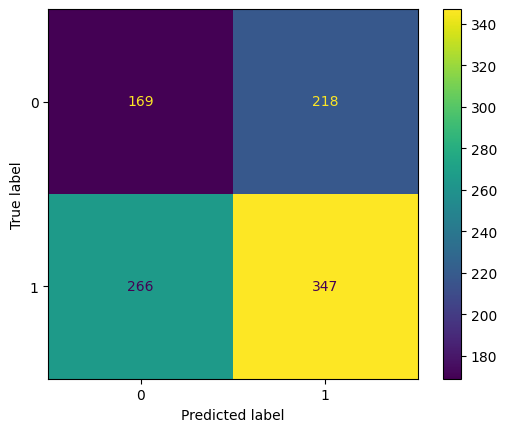

In [118]:
ConfusionMatrixDisplay.from_estimator(final_xgb, X_test_filtered, y_test)

In [119]:
X_train_filtered = pd.DataFrame(X_train_filtered)
X_test_filtered = pd.DataFrame(X_test_filtered)

ExactExplainer explainer: 1001it [00:14, 62.42it/s]                          


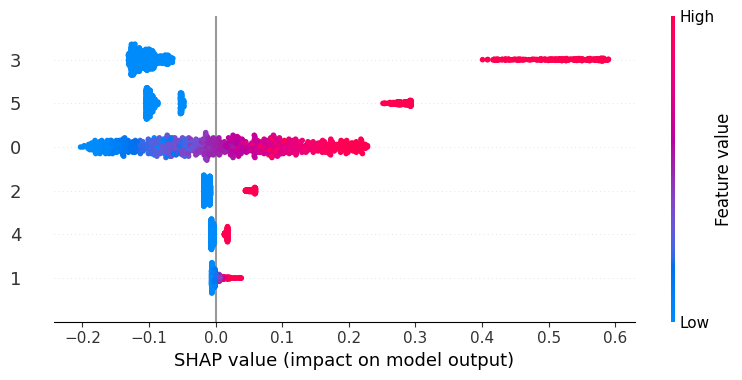

In [122]:
import shap

explainer = shap.Explainer(final_lr.predict_proba, X_train_filtered)
shap_values = explainer(X_test_filtered)

shap.summary_plot(shap_values[..., 1], X_test_filtered)